# 02 - Preprocesamiento del dataset dataset_original.csv

En este notebook se aplica el preprocesamiento necesario para preparar el dataset **San Francisco City Employee Salaries** para el modelado supervisado. Los pasos siguen la lógica propuesta en la guía del curso y en el notebook de referencia de la Semana 2, pero se documentan explícitamente para este trabajo:

1. Conversión de columnas numéricas almacenadas como texto.  
2. Eliminación de columnas irrelevantes para el modelado.  
3. Tratamiento de valores nulos.  
4. Eliminación de registros inconsistentes.  
5. Tratamiento de outliers (winsorización con IQR).  
6. Creación de nuevas variables (feature engineering).  
7. Definición de la variable objetivo de clasificación.  
8. División en conjuntos de entrenamiento y prueba.  
9. Escalado de variables numéricas.

In [1]:
# 0. Importaciones

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("Librerías importadas.")

Librerías importadas.


In [2]:
# 1. Carga del dataset original

ruta_dataset = "../data/raw/dataset_original.csv"  # ajusta si tu ruta es distinta

df = pd.read_csv(ruta_dataset, low_memory=False)

print(f"Dataset original cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas\n")
df.head()

Dataset original cargado: 148,654 filas, 13 columnas



,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.4300,567595.4300,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.2800,538909.2800,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.9100,335279.9100,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.6100,332343.6100,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.1900,326373.1900,2011,NaN,San Francisco,NaN


In [3]:
# 2. Conversión de columnas numéricas almacenadas como texto

columnas_numericas_texto = ["BasePay", "OvertimePay", "OtherPay", "Benefits"]

for col in columnas_numericas_texto:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Conversión a numérico completada para:", columnas_numericas_texto)
print(df[columnas_numericas_texto].dtypes)

Conversión a numérico completada para: ['BasePay', 'OvertimePay', 'OtherPay', 'Benefits']
BasePay        float64
OvertimePay    float64
OtherPay       float64
Benefits       float64
dtype: object


In [4]:
# 3. Eliminación de columnas irrelevantes

columnas_a_eliminar = ["Notes", "Status", "Agency", "Id"]

razones = {
    "Notes": "No aporta valor analítico relevante y puede contener texto libre o información no estructurada.",
    "Status": "No forma parte de las variables seleccionadas para el análisis predictivo.",
    "Agency": "Puede ser redundante o poco útil para el objetivo actual del modelo.",
    "Id": "Es un identificador único, por lo que no tiene valor predictivo."
}

columnas_presentes = [col for col in columnas_a_eliminar if col in df.columns]

print("=== Revisión de columnas a eliminar ===")

if columnas_presentes:
    for col in columnas_presentes:
        print(f"{col}: {razones[col]}")
    
    df = df.drop(columns=columnas_presentes)
    
    print("\nResultado: las columnas fueron eliminadas correctamente.")
    print(f"Columnas eliminadas: {columnas_presentes}")
else:
    print("Resultado: no se encontraron columnas coincidentes para eliminar.")

print("\nShape actual df:", df.shape)
print("Columnas actuales:", df.columns.tolist())

=== Revisión de columnas a eliminar ===
Notes: No aporta valor analítico relevante y puede contener texto libre o información no estructurada.
Status: No forma parte de las variables seleccionadas para el análisis predictivo.
Agency: Puede ser redundante o poco útil para el objetivo actual del modelo.
Id: Es un identificador único, por lo que no tiene valor predictivo.

Resultado: las columnas fueron eliminadas correctamente.
Columnas eliminadas: ['Notes', 'Status', 'Agency', 'Id']

Shape actual df: (148654, 9)
Columnas actuales: ['EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay', 'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year']


In [6]:
# 4. Tratamiento de valores nulos

# Ejemplo basado en el notebook de referencia:
# - BasePay: mediana global
# - Benefits: mediana por Year
# (ajusta o amplía según necesites)

if "BasePay" in df.columns:
    mediana_basepay = df["BasePay"].median()
    df["BasePay"] = df["BasePay"].fillna(mediana_basepay)

if "Benefits" in df.columns and "Year" in df.columns:
    df["Benefits"] = df.groupby("Year")["Benefits"].transform(lambda x: x.fillna(x.median()))

print("Valores nulos después de imputación:")
print(df.isnull().sum())

Valores nulos después de imputación:
EmployeeName            0
JobTitle                0
BasePay                 0
OvertimePay             4
OtherPay                4
Benefits            36159
TotalPay                0
TotalPayBenefits        0
Year                    0
dtype: int64


In [5]:
# 5. Eliminación de registros con TotalPay negativo

if "TotalPay" in df.columns:
    filas_antes = df.shape[0]
    df = df[df["TotalPay"] >= 0].copy()
    filas_despues = df.shape[0]
    
    print(f"Filas antes: {filas_antes:,}")
    print(f"Filas después de eliminar TotalPay negativos: {filas_despues:,}")

Filas antes: 148,654
Filas después de eliminar TotalPay negativos: 148,653


In [6]:
# 6. Winsorización con IQR para variables salariales

def winsorizacion_iqr(serie, factor=1.5):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    inferior = Q1 - factor * IQR
    superior = Q3 + factor * IQR
    return serie.clip(lower=inferior, upper=superior)

columnas_salario = [
    col for col in ["BasePay", "OvertimePay", "OtherPay", "Benefits", "TotalPay", "TotalPayBenefits"]
    if col in df.columns
]

df_clean = df.copy()

for col in columnas_salario:
    df_clean[col] = winsorizacion_iqr(df_clean[col])
    print(f"Winsorización aplicada a {col}")

print("\nShape df_clean:", df_clean.shape)

# A partir de aquí trabajaremos con df_clean como dataset procesado

Winsorización aplicada a BasePay
Winsorización aplicada a OvertimePay
Winsorización aplicada a OtherPay
Winsorización aplicada a Benefits
Winsorización aplicada a TotalPay
Winsorización aplicada a TotalPayBenefits

Shape df_clean: (148653, 9)


In [7]:
# 7. Feature engineering

# OvertimeRatio = OvertimePay / (BasePay + 1)
if "OvertimePay" in df_clean.columns and "BasePay" in df_clean.columns:
    df_clean["OvertimeRatio"] = df_clean["OvertimePay"] / (df_clean["BasePay"] + 1)

# BenefitsRatio = Benefits / (TotalPay + 1)
if "Benefits" in df_clean.columns and "TotalPay" in df_clean.columns:
    df_clean["BenefitsRatio"] = df_clean["Benefits"] / (df_clean["TotalPay"] + 1)

# LogTotalPay = log(1 + TotalPay)
if "TotalPay" in df_clean.columns:
    df_clean["LogTotalPay"] = np.log1p(df_clean["TotalPay"])

# Variable objetivo de clasificación: TieneOvertime (1 si OvertimePay > 0, 0 en caso contrario)
if "OvertimePay" in df_clean.columns:
    df_clean["TieneOvertime"] = (df_clean["OvertimePay"] > 0).astype(int)

print("Nuevas columnas creadas:", [col for col in ["OvertimeRatio", "BenefitsRatio", "LogTotalPay", "TieneOvertime"] if col in df_clean.columns])

Nuevas columnas creadas: ['OvertimeRatio', 'BenefitsRatio', 'LogTotalPay', 'TieneOvertime']


In [8]:
# 8. Codificación de JobTitle (top 30 + "Otro")
# agrupar títulos poco frecuentes y codificar con LabelEncoder

if "JobTitle" in df_clean.columns:
    top_jobs = df_clean["JobTitle"].value_counts().nlargest(30).index
    df_clean["JobTitleCat"] = df_clean["JobTitle"].where(df_clean["JobTitle"].isin(top_jobs), other="Otro")

    le = LabelEncoder()
    df_clean["JobTitleLabelEncoded"] = le.fit_transform(df_clean["JobTitleCat"])

    print("Codificación de JobTitle completada.")
    print("Ejemplo de categorías:", df_clean["JobTitleCat"].value_counts().head())
else:
    print("La columna 'JobTitle' no está disponible para codificación.")

Codificación de JobTitle completada.
Ejemplo de categorías: JobTitleCat
Otro                            96460
Transit Operator                 7036
Special Nurse                    4389
Registered Nurse                 3736
Public Svc Aide-Public Works     2518
Name: count, dtype: int64


In [9]:
# Un problema de clasificación (TieneOvertime) y uno de regresión (TotalPay).
# 9. Definición de features y variable objetivo

# Problema A: Clasificación - ¿Recibe overtime?
features_clf = [
    col for col in [
        "BasePay", "OtherPay", "Benefits", "Year",
        "BenefitsRatio", "LogTotalPay", "JobTitleLabelEncoded"
    ]
    if col in df_clean.columns
]

X_clf = df_clean[features_clf].copy()
y_clf = df_clean["TieneOvertime"].copy()

print("Problema A - Clasificación (TieneOvertime)")
print("Features:", features_clf)
print("Shape X_clf:", X_clf.shape, "y_clf:", y_clf.shape)

# Problema B: Regresión - ¿Cuánto gana en total?
features_reg = [
    col for col in [
        "Benefits", "Year", "BenefitsRatio", "JobTitleLabelEncoded"
    ]
    if col in df_clean.columns
]

X_reg = df_clean[features_reg].copy()
y_reg = df_clean["TotalPay"].copy()

print("\nProblema B - Regresión (TotalPay)")
print("Features:", features_reg)
print("Shape X_reg:", X_reg.shape, "y_reg:", y_reg.shape)

Problema A - Clasificación (TieneOvertime)
Features: ['BasePay', 'OtherPay', 'Benefits', 'Year', 'BenefitsRatio', 'LogTotalPay', 'JobTitleLabelEncoded']
Shape X_clf: (148653, 7) y_clf: (148653,)

Problema B - Regresión (TotalPay)
Features: ['Benefits', 'Year', 'BenefitsRatio', 'JobTitleLabelEncoded']
Shape X_reg: (148653, 4) y_reg: (148653,)


In [12]:
# Usamos train_test_split con estratificación en clasificación y escalado tipo StandardScaler
# 10. División train/test y escalado

# Clasificación
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc = scaler_c.transform(X_test_c)

print("Clasificación - Train:", X_train_c_sc.shape, "Test:", X_test_c_sc.shape)

# Regresión
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.20,
    random_state=42
)

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc = scaler_r.transform(X_test_r)

print("Regresión - Train:", X_train_r_sc.shape, "Test:", X_test_r_sc.shape)

Clasificación - Train: (118922, 7) Test: (29731, 7)
Regresión - Train: (118922, 4) Test: (29731, 4)


In [10]:
# Para usarlo luego en 03_modelado.ipynb y 04_evaluacion.ipynb
# 11. Guardado del dataset procesado

ruta_salida = "../data/processed/dataset_limpio.csv"

df_clean.to_csv(ruta_salida, index=False)

print(f"Dataset procesado guardado en: {ruta_salida}")
print("Shape final:", df_clean.shape)

Dataset procesado guardado en: ../data/processed/dataset_limpio.csv
Shape final: (148653, 15)


In [11]:
# Variable objetivo auxiliar para EDA: TieneOvertime (1 si OvertimePay > 0)
if "OvertimePay" in df.columns:
    df["TieneOvertime"] = (df["OvertimePay"] > 0).astype(int)
else:
    raise ValueError("La columna 'OvertimePay' no está disponible en el DataFrame df")

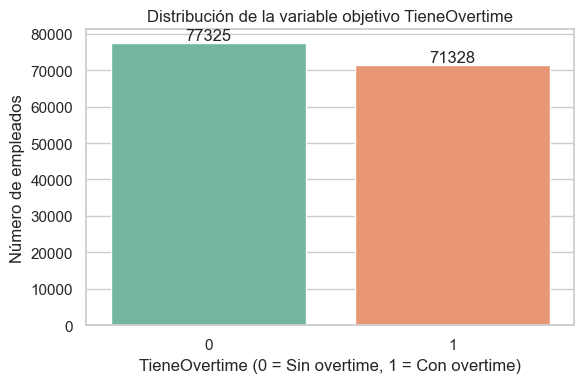

In [17]:
# Gráfico de distribución (conteo) y guardado
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
ax = sns.countplot(
    x="TieneOvertime",
    hue="TieneOvertime",
    data=df,
    palette="Set2",
    legend=False
)

ax.set_title("Distribución de la variable objetivo TieneOvertime")
ax.set_xlabel("TieneOvertime (0 = Sin overtime, 1 = Con overtime)")
ax.set_ylabel("Número de empleados")

# Añadir el valor (conteo) encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.savefig("../reports/figures/eda_distribucion_TieneOvertime.png", dpi=120)
plt.show()

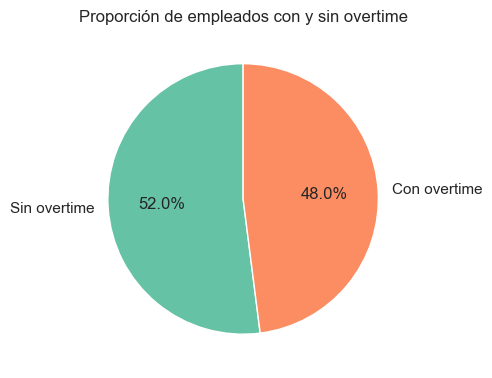

In [16]:
# Gráfico de proporción (pie) y guardado
import matplotlib.pyplot as plt

# Conteos
counts = df["TieneOvertime"].value_counts().sort_index()
labels = ["Sin overtime", "Con overtime"]  # 0 y 1

plt.figure(figsize=(5, 5))
plt.pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66c2a5", "#fc8d62"]
)
plt.title("Proporción de empleados con y sin overtime")

plt.tight_layout()
plt.savefig("../reports/figures/eda_proporcion_TieneOvertime.png", dpi=120)
plt.show()

## 12. Resumen del preprocesamiento

En este notebook se aplicaron los siguientes pasos clave al dataset `Salaries.csv`:

- Conversión de columnas numéricas almacenadas como texto (`BasePay`, `OvertimePay`, `OtherPay`, `Benefits`) a tipo numérico.
- Eliminación de columnas irrelevantes para el modelado (`Notes`, `Status`, `Agency`, `Id`), por tratarse de identificadores, texto libre o atributos no utilizados como predictores.
- Tratamiento de valores nulos, imputando valores razonables (por ejemplo, mediana global para `BasePay` y mediana por año para `Benefits`).
- Eliminación de registros con `TotalPay` negativo, considerados inconsistentes con el dominio del problema.
- Winsorización con IQR de las variables salariales para reducir la influencia de outliers extremos sin eliminar registros completos.
- Creación de nuevas variables (`OvertimeRatio`, `BenefitsRatio`, `LogTotalPay`) y de la variable objetivo de clasificación `TieneOvertime` a partir de `OvertimePay`.
- Codificación de `JobTitle` agrupando los 30 cargos más frecuentes y asignando el resto a la categoría `Otro`, para luego codificarlos numéricamente.
- Definición de conjuntos de variables predictoras y objetivos para dos problemas: clasificación (recibe overtime) y regresión (salario total).
- División del dataset en conjuntos de entrenamiento y prueba (80/20), con estratificación para el problema de clasificación, y aplicación de escalado estándar (`StandardScaler`) únicamente sobre los datos de entrenamiento.

El dataset resultante se guarda en `data/processed/dataset_limpio.csv` y será utilizado en los notebooks de **modelado** y **evaluación** para entrenar y comparar los modelos supervisados.